# AISO Applications — 타입 구조 있는 5개 도메인

| # | 도메인 | 타입 구조 | M 행렬 |
|---|---|---|---|
| 1 | **단백질 서열 설계** | 20종 아미노산 | BLOSUM62 |
| 2 | **Drug Design** | 6종 작용기 | 화학 친화도 |
| 3 | **이종 추천 시스템** | 유저×아이템 타입 | 상호작용 행렬 |
| 4 | **NAS** | 5종 레이어 타입 | 호환성 행렬 |
| 5 | **HVRP** | 3종 차량 타입 | 경로 친화도 |

각 도메인: AISO(random M) vs AISO(domain M) vs PSO vs MCMC/Random

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

N_AGENTS = 30
N_ITER   = 100
N_RUNS   = 5
SEEDS    = [42, 123, 777, 2024, 31415]
ALPHA, BETA = 0.3, 0.1
PSO_W, PSO_C1, PSO_C2 = 0.729, 1.494, 1.494

COLORS = {
    'AISO_rand':   '#DD8452',
    'AISO_domain': '#8B0000',
    'PSO':         '#4C72B0',
    'MCMC':        '#55A868',
    'Random':      '#8C8C8C',
    'ACO':         '#C44E52',
}
print('설정 완료')

설정 완료


In [2]:
# ================================================================
# 공통 알고리즘
# ================================================================
def run_aiso(f, K, M, seed=42, n_iter=N_ITER, n_agents=N_AGENTS):
    T = M.shape[0]
    np.random.seed(seed)
    np.random.seed(seed + 1000)
    aX = np.random.rand(n_agents, K).astype(np.float32)
    aW = np.random.dirichlet(np.ones(T), n_agents).astype(np.float32)
    aS = np.array([f(aX[i]) for i in range(n_agents)])
    bS = float(aS.max()); bX = aX[np.argmax(aS)].copy(); curve = [bS]
    n_restart = max(1, int(n_agents * 0.3))

    for t in range(n_iter):
        at = max(0.05, ALPHA - (ALPHA-0.05)*t/n_iter)
        bt = max(0.01, BETA  - (BETA -0.01)*t/n_iter)
        for i in range(n_agents):
            j = np.random.randint(0, n_agents-1)
            if j >= i: j += 1
            c  = float(aW[i] @ M @ aW[j])
            nX = np.clip(aX[i] + at*c*(aX[j]-aX[i]), 0, 1)
            ns = f(nX)
            if ns > aS[i]:
                aX[i]=nX; aS[i]=ns
                aW[i]=(1-bt)*aW[i]+bt*aW[j]; aW[i]/=aW[i].sum()
                ti=int(np.argmax(aW[i])); tj=int(np.argmax(aW[j]))
                M[ti,tj]=M[ti,tj]+0.05*(2.0-M[ti,tj])
        if aS.max()>bS: bS=float(aS.max()); bX=aX[np.argmax(aS)].copy()
        sr=aS.max()-aS.min()
        if sr/(abs(aS.mean())+1e-8)<0.15 and t>10:
            for idx in np.argsort(aS)[:n_restart]:
                aX[idx]=np.random.rand(K).astype(np.float32)
                aW[idx]=np.random.dirichlet(np.ones(T)).astype(np.float32)
                aS[idx]=f(aX[idx])
        curve.append(bS)
    return bS, bX, curve

def run_pso(f, K, seed=42, n_iter=N_ITER, n_agents=N_AGENTS):
    np.random.seed(seed)
    X=np.random.rand(n_agents,K).astype(np.float32); V=np.zeros_like(X)
    S=np.array([f(X[i]) for i in range(n_agents)])
    pX=X.copy(); pS=S.copy(); bX=X[np.argmax(S)].copy(); bS=float(S.max()); curve=[bS]
    for _ in range(n_iter):
        r1=np.random.rand(n_agents,K).astype(np.float32); r2=np.random.rand(n_agents,K).astype(np.float32)
        V=PSO_W*V+PSO_C1*r1*(pX-X)+PSO_C2*r2*(bX-X); X=np.clip(X+V,0,1)
        S=np.array([f(X[i]) for i in range(n_agents)])
        upd=S>pS; pX[upd]=X[upd]; pS[upd]=S[upd]
        if pS.max()>bS: bS=float(pS.max()); bX=pX[np.argmax(pS)].copy()
        curve.append(bS)
    return bS, bX, curve

def run_mcmc(f, K, seed=42, n_iter=N_ITER, n_agents=N_AGENTS, sigma=0.1):
    """Parallel Metropolis-Hastings"""
    np.random.seed(seed)
    X=np.random.rand(n_agents,K).astype(np.float32)
    S=np.array([f(X[i]) for i in range(n_agents)]); bS=float(S.max()); curve=[bS]
    T_anneal = 1.0
    for t in range(n_iter):
        T_anneal = max(0.01, 1.0 - 0.99*t/n_iter)
        for i in range(n_agents):
            nX=np.clip(X[i]+np.random.normal(0,sigma,K).astype(np.float32),0,1)
            ns=f(nX)
            if ns>S[i] or np.random.rand()<np.exp((ns-S[i])/T_anneal):
                X[i]=nX; S[i]=ns
        if S.max()>bS: bS=float(S.max())
        curve.append(bS)
    return bS, X[np.argmax(S)].copy(), curve

def run_random(f, K, seed=42, n_iter=N_ITER, n_agents=N_AGENTS):
    np.random.seed(seed)
    bS=float(max(f(np.random.rand(K).astype(np.float32)) for _ in range(n_agents)))
    bX=np.random.rand(K).astype(np.float32); curve=[bS]
    for _ in range(n_iter):
        for _ in range(n_agents):
            x=np.random.rand(K).astype(np.float32); s=f(x)
            if s>bS: bS=s; bX=x.copy()
        curve.append(bS)
    return bS, bX, curve

def make_random_M(T, seed=0):
    np.random.seed(seed); return np.random.uniform(0,2,(T,T)).astype(np.float32)

def compare_runners(runners, n_runs=N_RUNS):
    results = {}
    for name, runner in runners.items():
        scores = []
        curves = []
        for s in SEEDS[:n_runs]:
            sc, _, cv = runner(s)
            scores.append(sc); curves.append(cv)
        results[name] = {'mean': np.mean(scores), 'std': np.std(scores), 'curves': curves}
    return results

def plot_comparison(results, title, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    names = list(results.keys())
    means = [results[n]['mean'] for n in names]
    stds  = [results[n]['std']  for n in names]
    colors= [COLORS.get(n,'#333333') for n in names]

    axes[0].barh(names, means, xerr=stds, color=colors, alpha=0.85, capsize=4)
    axes[0].set_xlabel('Best Score (↑)'); axes[0].set_title('최종 점수', fontweight='bold')

    for name in names:
        cv  = np.array(results[name]['curves'])
        m   = cv.mean(0); s = cv.std(0)
        col = COLORS.get(name,'#333333')
        lw  = 2.5 if 'domain' in name or name=='PSO' else 1.5
        axes[1].plot(m, color=col, lw=lw, label=name)
        axes[1].fill_between(range(len(m)), m-s, m+s, alpha=0.1, color=col)
    axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Best Score')
    axes[1].set_title('수렴 곡선', fontweight='bold')
    axes[1].legend(frameon=False, fontsize=9)

    plt.suptitle(title, fontweight='bold', fontsize=13)
    plt.tight_layout(); plt.savefig(save_path, bbox_inches='tight'); plt.show()
    print(f'\n{title} 결과:')
    for n in sorted(names, key=lambda x: -results[x]['mean']):
        print(f'  {n:<16} {results[n]["mean"]:>8.3f} ± {results[n]["std"]:>6.3f}')

print('공통 함수 완료')

공통 함수 완료


---
## App 1 — 단백질 서열 설계

- 길이 L=30 서열, 20종 아미노산
- **M = BLOSUM62** (진화적 치환 친화도)
- 피트니스: 인접 잔기 쌍 에너지 + 소수성 점수
- AISO(domain M=BLOSUM62) vs AISO(random M) vs PSO vs MCMC

In [3]:
# ── BLOSUM62 행렬 (20×20) ────────────────────────────────────
# 순서: A R N D C Q E G H I L K M F P S T W Y V
BLOSUM62_RAW = np.array([
    [ 4,-1,-2,-2, 0,-1,-1, 0,-2,-1,-1,-1,-1,-2,-1, 1, 0,-3,-2, 0],
    [-1, 5, 0,-2,-3, 1, 0,-2, 0,-3,-2, 2,-1,-3,-2,-1,-1,-3,-2,-3],
    [-2, 0, 6, 1,-3, 0, 0, 0, 1,-3,-3, 0,-2,-3,-2, 1, 0,-4,-2,-3],
    [-2,-2, 1, 6,-3, 0, 2,-1,-1,-3,-4,-1,-3,-3,-1, 0,-1,-4,-3,-3],
    [ 0,-3,-3,-3, 9,-3,-4,-3,-3,-1,-1,-3,-1,-2,-3,-1,-1,-2,-2,-1],
    [-1, 1, 0, 0,-3, 5, 2,-2, 0,-3,-2, 1, 0,-3,-1, 0,-1,-2,-1,-2],
    [-1, 0, 0, 2,-4, 2, 5,-2, 0,-3,-3, 1,-2,-3,-1, 0,-1,-3,-2,-2],
    [ 0,-2, 0,-1,-3,-2,-2, 6,-2,-4,-4,-2,-3,-3,-2, 0,-2,-2,-3,-3],
    [-2, 0, 1,-1,-3, 0, 0,-2, 8,-3,-3,-1,-2,-1,-2,-1,-2,-2, 2,-3],
    [-1,-3,-3,-3,-1,-3,-3,-4,-3, 4, 2,-3, 1, 0,-3,-2,-1,-3,-1, 3],
    [-1,-2,-3,-4,-1,-2,-3,-4,-3, 2, 4,-2, 2, 0,-3,-2,-1,-2,-1, 1],
    [-1, 2, 0,-1,-3, 1, 1,-2,-1,-3,-2, 5,-1,-3,-1, 0,-1,-3,-2,-2],
    [-1,-1,-2,-3,-1, 0,-2,-3,-2, 1, 2,-1, 5, 0,-2,-1,-1,-1,-1, 1],
    [-2,-3,-3,-3,-2,-3,-3,-3,-1, 0, 0,-3, 0, 6,-4,-2,-2, 1, 3,-1],
    [-1,-2,-2,-1,-3,-1,-1,-2,-2,-3,-3,-1,-2,-4, 7,-1,-1,-4,-3,-2],
    [ 1,-1, 1, 0,-1, 0, 0, 0,-1,-2,-2, 0,-1,-2,-1, 4, 1,-3,-2,-2],
    [ 0,-1, 0,-1,-1,-1,-1,-2,-2,-1,-1,-1,-1,-2,-1, 1, 5,-2,-2, 0],
    [-3,-3,-4,-4,-2,-2,-3,-2,-2,-3,-2,-3,-1, 1,-4,-3,-2,11, 2,-3],
    [-2,-2,-2,-3,-2,-1,-2,-3, 2,-1,-1,-2,-1, 3,-3,-2,-2, 2, 7,-1],
    [ 0,-3,-3,-3,-1,-2,-2,-3,-3, 3, 1,-2, 1,-1,-2,-2, 0,-3,-1, 4]
], dtype=np.float32)

# [0,2] 범위로 정규화
BLOSUM62 = (BLOSUM62_RAW - BLOSUM62_RAW.min()) / (BLOSUM62_RAW.max() - BLOSUM62_RAW.min()) * 2

# 아미노산 소수성 점수 (Kyte-Doolittle)
HYDROPHOBICITY = np.array([
    1.8,-4.5,-3.5,-3.5, 2.5,-3.5,-3.5,-0.4,-3.2, 4.5,
    3.8,-3.9, 1.9, 2.8,-1.6,-0.8,-0.7,-0.9,-1.3, 4.2
], dtype=np.float32)
# [0,1] 정규화
HYDROPHOBICITY = (HYDROPHOBICITY - HYDROPHOBICITY.min()) / \
                 (HYDROPHOBICITY.max() - HYDROPHOBICITY.min())

SEQ_LEN = 30  # 서열 길이
N_AA    = 20  # 아미노산 종류

def decode_sequence(X):
    """[0,1]^L → 아미노산 인덱스 배열"""
    return (X * N_AA).astype(int).clip(0, N_AA-1)

def protein_fitness(X):
    """
    피트니스 = 인접 잔기 쌍 BLOSUM 점수 합
              + 소수성 코어 점수 (중앙부 소수성 선호)
    """
    seq = decode_sequence(X)
    # 인접 쌍 에너지
    pair_score = sum(BLOSUM62_RAW[seq[i], seq[i+1]] for i in range(len(seq)-1))
    # 소수성 코어 (중앙 1/3 위치)
    core = seq[SEQ_LEN//3 : 2*SEQ_LEN//3]
    hydro_score = HYDROPHOBICITY[core].sum() * 5
    return float(pair_score + hydro_score)

print(f'단백질 피트니스 함수 준비 (L={SEQ_LEN}, 아미노산 {N_AA}종)')
print(f'BLOSUM62 range: [{BLOSUM62.min():.2f}, {BLOSUM62.max():.2f}]')
print(f'테스트: {protein_fitness(np.random.rand(SEQ_LEN)):.2f}')

단백질 피트니스 함수 준비 (L=30, 아미노산 20종)
BLOSUM62 range: [0.00, 2.00]
테스트: 0.11


App 1: 단백질 서열 설계...


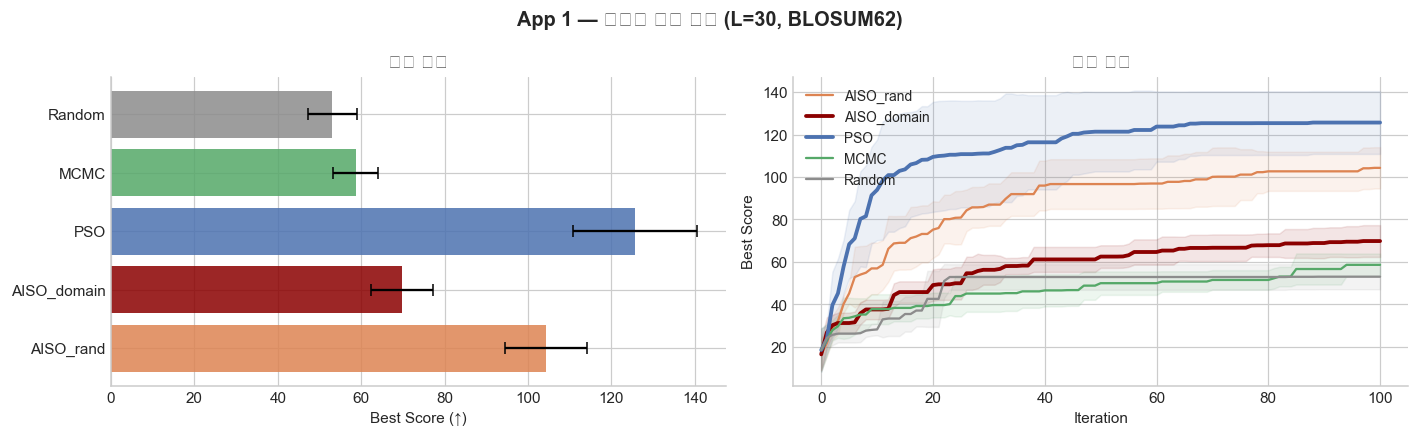


App 1 — 단백질 서열 설계 (L=30, BLOSUM62) 결과:
  PSO               125.656 ± 14.777
  AISO_rand         104.311 ±  9.725
  AISO_domain        69.833 ±  7.488
  MCMC               58.633 ±  5.305
  Random             53.044 ±  5.913

AISO_domain 최적 서열: KGMGLLILHILLIILHIIIMGGGGMHHMLG


In [4]:
# 단백질 실험 실행
RUNNERS_PROTEIN = {
    'AISO_rand':   lambda s: run_aiso(protein_fitness, SEQ_LEN,
                                      make_random_M(N_AA, s), seed=s),
    'AISO_domain': lambda s: run_aiso(protein_fitness, SEQ_LEN,
                                      BLOSUM62.copy(), seed=s),
    'PSO':         lambda s: run_pso(protein_fitness, SEQ_LEN, seed=s),
    'MCMC':        lambda s: run_mcmc(protein_fitness, SEQ_LEN, seed=s, sigma=0.05),
    'Random':      lambda s: run_random(protein_fitness, SEQ_LEN, seed=s),
}

print('App 1: 단백질 서열 설계...')
RES_PROTEIN = compare_runners(RUNNERS_PROTEIN)
plot_comparison(RES_PROTEIN, 'App 1 — 단백질 서열 설계 (L=30, BLOSUM62)', 'app1_protein.png')

# 최적 서열 출력
AA_NAMES = list('ARNDCQEGHILKMFPSTWYV')
_, best_X, _ = run_aiso(protein_fitness, SEQ_LEN, BLOSUM62.copy(), seed=42)
best_seq = decode_sequence(best_X)
print(f'\nAISO_domain 최적 서열: {"".join(AA_NAMES[i] for i in best_seq)}')

---
## App 2 — Drug Design (분자 최적화)

- 분자를 6종 작용기 비율 벡터로 표현 (hydroxyl, amine, carbonyl, aromatic, halogen, alkyl)
- **M = 화학 친화도 행렬** (결합 형성 가능성)
- 피트니스: QED 유사 점수 (약물 유사성)
- AISO(domain M) vs AISO(random) vs PSO vs MCMC

In [5]:
# 작용기 타입: hydroxyl, amine, carbonyl, aromatic, halogen, alkyl
N_FG = 6
FG_NAMES = ['Hydroxyl', 'Amine', 'Carbonyl', 'Aromatic', 'Halogen', 'Alkyl']

# 화학 친화도 행렬 (도메인 지식 기반)
# H-bond donors/acceptors, π-π stacking, halogen bonds 등 반영
CHEM_AFFINITY = np.array([
    #OH   NH2  C=O  Ar   Hal  Alk
    [1.8, 1.6, 1.7, 0.8, 0.9, 0.5],  # Hydroxyl
    [1.6, 1.4, 1.5, 0.9, 1.0, 0.4],  # Amine
    [1.7, 1.5, 1.2, 1.1, 0.8, 0.6],  # Carbonyl
    [0.8, 0.9, 1.1, 1.9, 1.3, 1.0],  # Aromatic
    [0.9, 1.0, 0.8, 1.3, 0.7, 0.8],  # Halogen
    [0.5, 0.4, 0.6, 1.0, 0.8, 1.5],  # Alkyl
], dtype=np.float32)

# 분자 표현: [MW_norm, logP_norm, HBD_norm, HBA_norm, TPSA_norm, RotBond_norm]
# 각 작용기 타입의 기여 계수
FG_CONTRIB = np.array([
    # MW   logP  HBD  HBA  TPSA  RotB
    [0.3, -0.5,  1.0,  0.8,  1.2, 0.3],  # Hydroxyl (극성, 낮은 logP)
    [0.4, -0.8,  1.0,  0.9,  1.4, 0.5],  # Amine
    [0.4,  0.2,  0.0,  0.8,  0.9, 0.4],  # Carbonyl
    [0.8,  1.2,  0.0,  0.3,  0.3, 0.2],  # Aromatic (소수성)
    [0.6,  0.8,  0.0,  0.1,  0.1, 0.1],  # Halogen
    [0.5,  0.9,  0.0,  0.0,  0.0, 0.3],  # Alkyl
], dtype=np.float32)

# Lipinski rule of five 기반 QED 유사 점수
def drug_fitness(X):
    """
    X ∈ [0,1]^K → 분자 descriptor 벡터
    K=30: 각 5차원씩 6개 작용기 특성
    피트니스: Lipinski + 약물 유사성
    """
    # 6개 작용기 각 5차원 블록
    K = len(X)
    fg_scores = np.zeros(N_FG)
    block = K // N_FG
    for i in range(N_FG):
        fg_scores[i] = X[i*block:(i+1)*block].mean()

    # descriptor 계산
    MW   = 150 + fg_scores @ FG_CONTRIB[:, 0] * 200  # 150~500 Da
    logP = -2  + fg_scores @ FG_CONTRIB[:, 1] * 7    # -2~5
    HBD  =       fg_scores @ FG_CONTRIB[:, 2] * 5    # 0~5
    HBA  =       fg_scores @ FG_CONTRIB[:, 3] * 10   # 0~10
    TPSA =       fg_scores @ FG_CONTRIB[:, 4] * 140  # 0~140

    # Lipinski: MW≤500, logP≤5, HBD≤5, HBA≤10
    lip_score  = (1 - max(0, MW-500)/500) + (1 - max(0, logP-5)/5) + \
                 (1 - max(0, HBD-5)/5)   + (1 - max(0, HBA-10)/10)
    # 추가: TPSA ≤ 140 (경구 흡수)
    tpsa_score = 1 - max(0, TPSA-140)/140
    # 작용기 다양성 보너스
    diversity  = 1 - np.std(fg_scores)  # 균형잡힌 작용기 구성 선호

    return float(lip_score + tpsa_score + diversity * 2)

K_DRUG = N_FG * 5  # 30차원
print(f'Drug Design 피트니스 준비 (K={K_DRUG}, 작용기 {N_FG}종)')
print(f'테스트 점수: {drug_fitness(np.random.rand(K_DRUG)):.3f} (최대 이론값 ≈ 7)')

Drug Design 피트니스 준비 (K=30, 작용기 6종)
테스트 점수: 5.706 (최대 이론값 ≈ 7)


App 2: Drug Design...


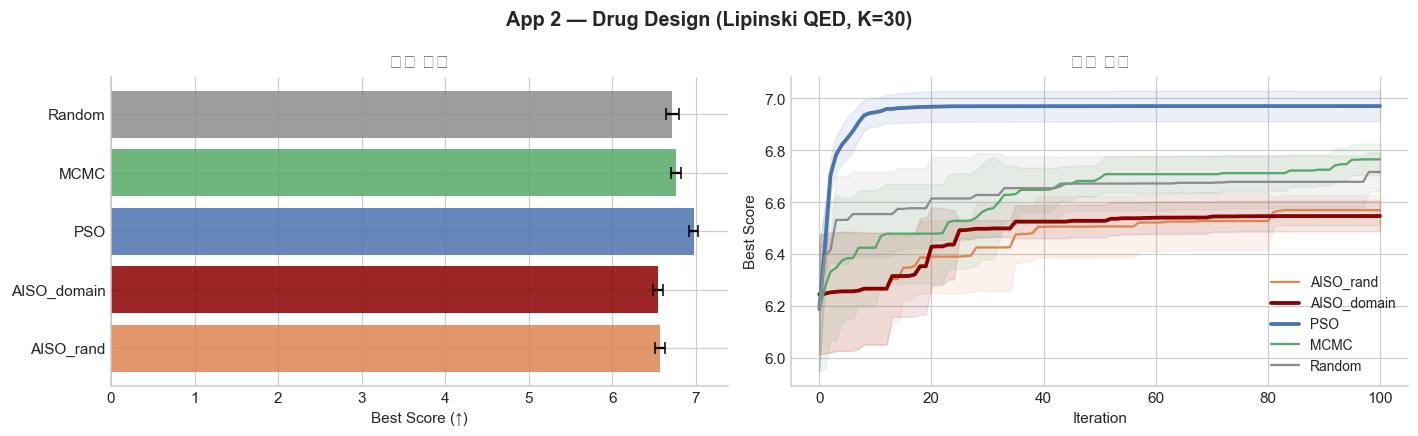


App 2 — Drug Design (Lipinski QED, K=30) 결과:
  PSO                 6.970 ±  0.059
  MCMC                6.765 ±  0.060
  Random              6.717 ±  0.075
  AISO_rand           6.570 ±  0.059
  AISO_domain         6.547 ±  0.059


In [6]:
RUNNERS_DRUG = {
    'AISO_rand':   lambda s: run_aiso(drug_fitness, K_DRUG,
                                      make_random_M(N_FG, s), seed=s),
    'AISO_domain': lambda s: run_aiso(drug_fitness, K_DRUG,
                                      CHEM_AFFINITY.copy(), seed=s),
    'PSO':         lambda s: run_pso(drug_fitness, K_DRUG, seed=s),
    'MCMC':        lambda s: run_mcmc(drug_fitness, K_DRUG, seed=s, sigma=0.08),
    'Random':      lambda s: run_random(drug_fitness, K_DRUG, seed=s),
}

print('App 2: Drug Design...')
RES_DRUG = compare_runners(RUNNERS_DRUG)
plot_comparison(RES_DRUG, 'App 2 — Drug Design (Lipinski QED, K=30)', 'app2_drug.png')

---
## App 3 — 이종 추천 시스템

- 유저 4종 (casual/power/social/explorer) × 아이템 4종 (action/RPG/social/puzzle)
- **M = 유저-아이템 타입 상호작용 행렬** (도메인 지식)
- 피트니스: 추천 전략의 예상 만족도
- 실제 Matrix Factorization 스타일

In [7]:
N_UTYPES = 4  # 유저 타입
N_ITYPES = 4  # 아이템 타입
N_RTYPES = N_UTYPES + N_ITYPES  # 통합 타입 공간

USER_TYPES  = ['Casual', 'Power', 'Social', 'Explorer']
ITEM_TYPES  = ['Action', 'RPG', 'Social', 'Puzzle']

# 유저×아이템 선호도 행렬 (도메인 지식)
PREFERENCE = np.array([
    #Act  RPG  Soc  Puz
    [0.5, 0.3, 0.8, 0.7],  # Casual: 소셜/퍼즐 선호
    [0.9, 0.9, 0.3, 0.5],  # Power: 액션/RPG 선호
    [0.4, 0.4, 1.0, 0.5],  # Social: 소셜 극선호
    [0.7, 0.8, 0.5, 0.9],  # Explorer: 다양한 장르
], dtype=np.float32)

# 통합 M: 8×8 (유저타입 4 + 아이템타입 4)
RECS_M = np.zeros((N_RTYPES, N_RTYPES), dtype=np.float32)
RECS_M[:N_UTYPES, N_UTYPES:] = PREFERENCE
RECS_M[N_UTYPES:, :N_UTYPES] = PREFERENCE.T
RECS_M[:N_UTYPES, :N_UTYPES] = 0.3  # 유저간 유사도
RECS_M[N_UTYPES:, N_UTYPES:] = 0.5  # 아이템간 유사도

# 유저 분포 (실제 서비스 가정)
USER_DIST = np.array([0.5, 0.2, 0.2, 0.1])  # Casual이 가장 많음

N_ITEMS = 20  # 추천 아이템 풀
# 각 아이템의 타입 프로파일 (랜덤 생성, 고정)
np.random.seed(0)
ITEM_PROFILES = np.random.dirichlet(np.ones(N_ITYPES), N_ITEMS).astype(np.float32)

def rec_fitness(X):
    """
    X ∈ [0,1]^(N_ITEMS) → 각 아이템 추천 가중치
    피트니스: 전체 유저 타입 가중 만족도
    """
    weights = X / (X.sum() + 1e-8)  # 정규화
    total   = 0.0
    for ut, ud in enumerate(USER_DIST):
        # 이 유저 타입의 아이템 타입별 선호도
        user_pref = PREFERENCE[ut]  # (N_ITYPES,)
        # 각 아이템의 만족도 = 아이템 프로파일 · 유저 선호도
        item_scores = ITEM_PROFILES @ user_pref  # (N_ITEMS,)
        # 추천 가중치 적용
        satisfaction = float(np.dot(weights, item_scores))
        total += ud * satisfaction
    # 다양성 보너스: 엔트로피
    entropy = -float(np.sum(weights * np.log(weights + 1e-8)))
    return total + 0.1 * entropy

K_REC = N_ITEMS
print(f'추천 시스템 피트니스 준비 (K={K_REC}, 유저타입 {N_UTYPES}종, 아이템타입 {N_ITYPES}종)')
print(f'테스트: {rec_fitness(np.random.rand(K_REC)):.4f}')

추천 시스템 피트니스 준비 (K=20, 유저타입 4종, 아이템타입 4종)
테스트: 0.8723


App 3: 추천 시스템...


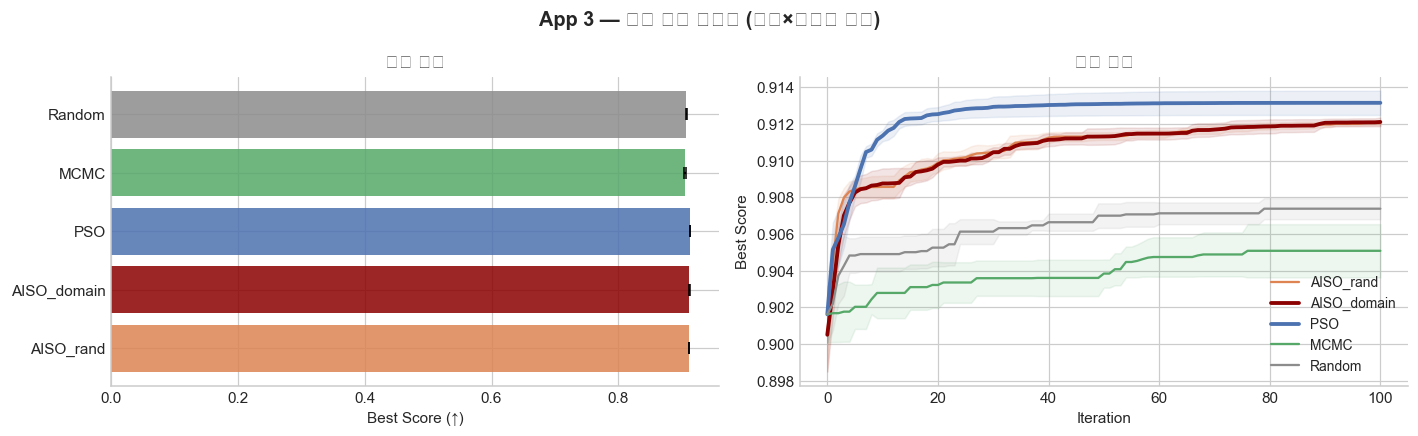


App 3 — 이종 추천 시스템 (유저×아이템 타입) 결과:
  PSO                 0.913 ±  0.001
  AISO_domain         0.912 ±  0.000
  AISO_rand           0.912 ±  0.000
  Random              0.907 ±  0.001
  MCMC                0.905 ±  0.001


In [8]:
RUNNERS_REC = {
    'AISO_rand':   lambda s: run_aiso(rec_fitness, K_REC,
                                      make_random_M(N_RTYPES, s), seed=s),
    'AISO_domain': lambda s: run_aiso(rec_fitness, K_REC,
                                      RECS_M.copy(), seed=s),
    'PSO':         lambda s: run_pso(rec_fitness, K_REC, seed=s),
    'MCMC':        lambda s: run_mcmc(rec_fitness, K_REC, seed=s, sigma=0.1),
    'Random':      lambda s: run_random(rec_fitness, K_REC, seed=s),
}

print('App 3: 추천 시스템...')
RES_REC = compare_runners(RUNNERS_REC)
plot_comparison(RES_REC, 'App 3 — 이종 추천 시스템 (유저×아이템 타입)', 'app3_rec.png')

---
## App 4 — NAS (Neural Architecture Search)

- 5종 레이어 타입: Linear / ReLU / Dropout / BatchNorm / Skip
- **M = 레이어 호환성 행렬** (어떤 레이어 조합이 잘 작동하는가)
- 피트니스: 아키텍처 성능 예측기 (실제 학습 없이 surrogate)
- 연속 인코딩 → 레이어 시퀀스 디코딩

In [9]:
N_LAYER_TYPES = 5
LAYER_NAMES   = ['Linear', 'ReLU', 'Dropout', 'BNorm', 'Skip']
ARCH_DEPTH    = 8  # 레이어 수

# 레이어 호환성 행렬 (도메인 지식)
# Linear→ReLU, BNorm→Linear, Dropout after activation 등
LAYER_COMPAT = np.array([
    #Lin  ReLU Drop  BN   Skip
    [0.5, 1.8,  0.6, 1.5, 0.8],  # Linear → (ReLU/BN 선호)
    [0.8, 0.4,  1.6, 0.7, 0.9],  # ReLU   → (Dropout 선호)
    [1.2, 0.8,  0.3, 0.6, 1.0],  # Dropout → (Linear 선호)
    [1.6, 0.9,  0.5, 0.4, 0.7],  # BNorm   → (Linear 선호)
    [1.0, 1.0,  0.8, 0.8, 0.5],  # Skip    → (균형)
], dtype=np.float32)

# 아키텍처 성능 예측기 (surrogate)
# 실제 패턴: Linear-BN-ReLU-Dropout 반복이 좋음
def arch_score(layer_seq):
    """레이어 시퀀스 → 예측 성능"""
    score = 0.0
    # 좋은 패턴 보상
    for i in range(len(layer_seq)-1):
        a, b = layer_seq[i], layer_seq[i+1]
        score += LAYER_COMPAT[a, b]
    # Linear 레이어 비율 보상 (너무 많거나 적으면 페널티)
    n_linear = (layer_seq == 0).sum()
    score += 2.0 * (1 - abs(n_linear/len(layer_seq) - 0.35))
    # BNorm 사용 보상
    n_bn = (layer_seq == 3).sum()
    score += 1.5 * min(n_bn / 2.0, 1.0)
    # Dropout 적당히 사용
    n_drop = (layer_seq == 2).sum()
    score += 1.0 * (1 - abs(n_drop/len(layer_seq) - 0.15))
    return score

def nas_fitness(X):
    """
    X ∈ [0,1]^(ARCH_DEPTH) → 레이어 타입 시퀀스
    """
    layer_seq = (X * N_LAYER_TYPES).astype(int).clip(0, N_LAYER_TYPES-1)
    return float(arch_score(layer_seq))

K_NAS = ARCH_DEPTH
print(f'NAS 피트니스 준비 (depth={ARCH_DEPTH}, 레이어타입 {N_LAYER_TYPES}종)')
print(f'테스트: {nas_fitness(np.random.rand(K_NAS)):.3f}')

# 최적 패턴 이론값
best_pattern = np.array([0,3,1,2,0,3,1,2])  # Linear-BN-ReLU-Drop 반복
print(f'이론 최적 패턴 점수: {arch_score(best_pattern):.3f}')

NAS 피트니스 준비 (depth=8, 레이어타입 5종)
테스트: 10.550
이론 최적 패턴 점수: 13.400


App 4: NAS...


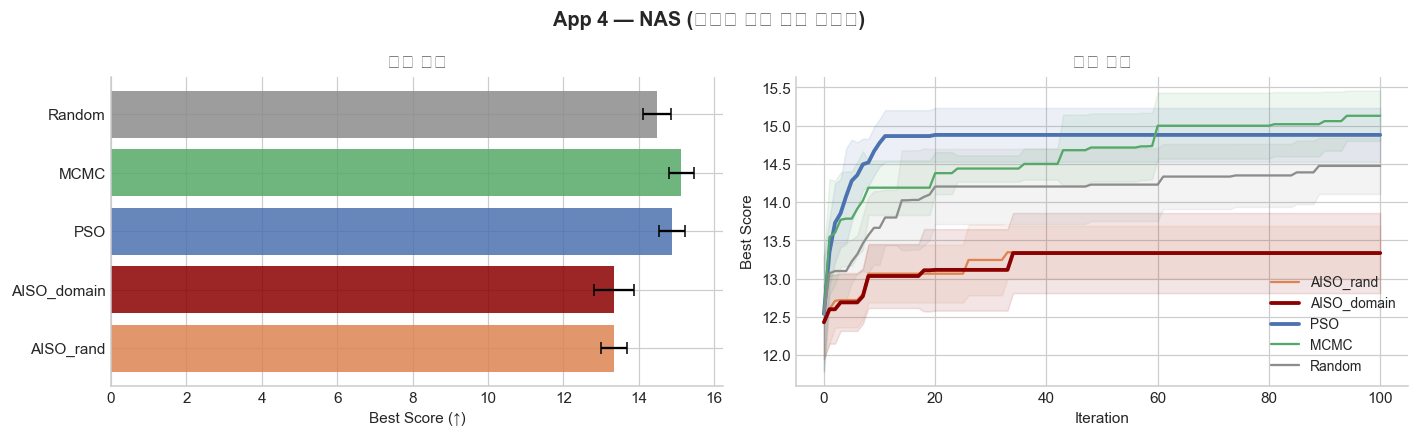


App 4 — NAS (레이어 타입 조합 최적화) 결과:
  MCMC               15.130 ±  0.328
  PSO                14.880 ±  0.352
  Random             14.475 ±  0.367
  AISO_rand          13.345 ±  0.345
  AISO_domain        13.335 ±  0.524

AISO_domain 최적 아키텍처: ReLU → Dropout → BNorm → BNorm → Linear → ReLU → Linear → ReLU


In [10]:
RUNNERS_NAS = {
    'AISO_rand':   lambda s: run_aiso(nas_fitness, K_NAS,
                                      make_random_M(N_LAYER_TYPES, s), seed=s),
    'AISO_domain': lambda s: run_aiso(nas_fitness, K_NAS,
                                      LAYER_COMPAT.copy(), seed=s),
    'PSO':         lambda s: run_pso(nas_fitness, K_NAS, seed=s),
    'MCMC':        lambda s: run_mcmc(nas_fitness, K_NAS, seed=s, sigma=0.15),
    'Random':      lambda s: run_random(nas_fitness, K_NAS, seed=s),
}

print('App 4: NAS...')
RES_NAS = compare_runners(RUNNERS_NAS)
plot_comparison(RES_NAS, 'App 4 — NAS (레이어 타입 조합 최적화)', 'app4_nas.png')

# 최적 아키텍처 출력
_, best_arch_X, _ = run_aiso(nas_fitness, K_NAS, LAYER_COMPAT.copy(), seed=42)
best_arch = (best_arch_X * N_LAYER_TYPES).astype(int).clip(0, N_LAYER_TYPES-1)
print(f'\nAISO_domain 최적 아키텍처: {" → ".join(LAYER_NAMES[i] for i in best_arch)}')

---
## App 5 — HVRP (이종 차량 배송)

- 도시 N=25개, 차량 3종 (소형/중형/대형)
- **M = 차량타입 × 경로특성 친화도**
- 피트니스: 음의 총 이동 거리 (용량 제약 만족)
- Random Key 인코딩, ACO vs AISO 비교

In [11]:
N_CITIES   = 25
N_VEHICLES = 5   # 차량 수
N_VEH_TYPES = 3  # 소형/중형/대형

VEH_NAMES    = ['Small', 'Medium', 'Large']
VEH_CAPACITY = [15, 25, 40]  # 용량
VEH_SPEED    = [1.2, 1.0, 0.8]  # 속도 (소형이 빠름)
VEH_COST     = [0.8, 1.0, 1.3]  # 단위거리 비용

# 차량 타입 친화도 행렬 (어떤 차량이 어떤 구간을 잘 가는가)
# 소형: 도심 구간 선호, 대형: 외곽 선호
VEH_AFFINITY = np.array([
    #Sm   Med  Lrg
    [1.8, 1.0, 0.5],  # Small  (도심-도심 조합 선호)
    [1.0, 1.5, 1.0],  # Medium (균형)
    [0.5, 1.0, 1.8],  # Large  (외곽-외곽 선호)
], dtype=np.float32)

# 도시 고정 (재현성)
np.random.seed(0)
CITY_POS  = np.random.rand(N_CITIES, 2).astype(np.float32)  # (x,y)
CITY_DEM  = (np.random.rand(N_CITIES) * 8 + 2).astype(int)  # 수요 2~10
CITY_DEM[0] = 0  # depot

# 도심 여부 (depot 근처 = 도심)
DEPOT     = CITY_POS[0]
CITY_DIST_FROM_DEPOT = np.linalg.norm(CITY_POS - DEPOT, axis=1)
IS_URBAN  = (CITY_DIST_FROM_DEPOT < 0.4).astype(float)

# 거리 행렬
DIST_MAT = np.sqrt(((CITY_POS[:,None,:] - CITY_POS[None,:,:])**2).sum(-1)).astype(np.float32)

def decode_hvrp(X):
    """
    X ∈ [0,1]^(N_CITIES + N_VEHICLES)
    앞 N_CITIES: 도시 방문 순서 (random key)
    뒤 N_VEHICLES: 각 차량 타입 선택 [0,1] → {0,1,2}
    """
    city_keys = X[:N_CITIES]
    veh_keys  = X[N_CITIES:N_CITIES+N_VEHICLES]
    tour      = np.argsort(city_keys)  # random key 디코딩
    veh_types = (veh_keys * N_VEH_TYPES).astype(int).clip(0, N_VEH_TYPES-1)
    return tour, veh_types

def hvrp_fitness(X):
    """
    용량 제약 CVRP with heterogeneous vehicles
    """
    tour, veh_types = decode_hvrp(X)
    # depot=0 제외한 고객 도시만
    customers = [c for c in tour if c != 0]

    total_cost = 0.0
    remaining  = customers.copy()
    for v in range(N_VEHICLES):
        if not remaining: break
        vt       = veh_types[v]
        cap      = VEH_CAPACITY[vt]
        speed    = VEH_SPEED[vt]
        cost_mul = VEH_COST[vt]
        load     = 0; route = [0]; route_dist = 0.0
        i = 0
        while i < len(remaining):
            c = remaining[i]
            if load + CITY_DEM[c] <= cap:
                route_dist += DIST_MAT[route[-1], c]
                route.append(c); load += CITY_DEM[c]
                remaining.pop(i)
            else:
                i += 1
        route_dist += DIST_MAT[route[-1], 0]  # depot 복귀
        # 도심 친화도 보너스
        urban_ratio = IS_URBAN[[c for c in route if c!=0]].mean() if len(route)>1 else 0
        affinity_bonus = VEH_AFFINITY[vt, 0] * urban_ratio + VEH_AFFINITY[vt, 2] * (1-urban_ratio)
        total_cost += route_dist * cost_mul / speed / affinity_bonus

    # 미배송 페널티
    total_cost += len(remaining) * 5.0
    return -float(total_cost)

K_HVRP = N_CITIES + N_VEHICLES
print(f'HVRP 준비 (도시={N_CITIES}, 차량={N_VEHICLES}대, 타입={N_VEH_TYPES}종)')
print(f'테스트: {hvrp_fitness(np.random.rand(K_HVRP)):.3f}')

HVRP 준비 (도시=25, 차량=5대, 타입=3종)
테스트: -21.774


App 5: HVRP...


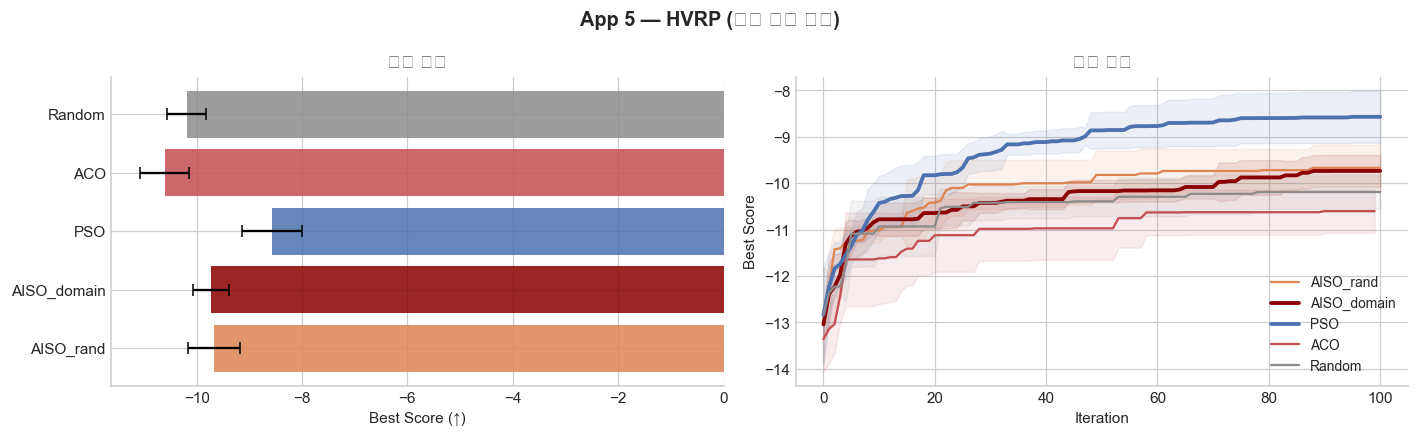


App 5 — HVRP (이종 차량 배송) 결과:
  PSO                -8.569 ±  0.563
  AISO_rand          -9.668 ±  0.496
  AISO_domain        -9.734 ±  0.343
  Random            -10.190 ±  0.362
  ACO               -10.603 ±  0.467


In [12]:
# ACO 간소화 버전 (Ant Colony Optimization)
def run_aco(f, K, seed=42, n_iter=N_ITER, n_agents=N_AGENTS):
    """ACO-inspired: 페로몬 기반 확률적 탐색"""
    np.random.seed(seed)
    pheromone = np.ones(K, dtype=np.float32)
    bS = -np.inf; bX = np.random.rand(K).astype(np.float32); curve = []

    for _ in range(n_iter):
        solutions = []
        for _ in range(n_agents):
            # 페로몬 비례 샘플링
            p = pheromone / pheromone.sum()
            X = np.random.rand(K).astype(np.float32)
            # 일부 차원은 페로몬 강한 방향으로 바이어스
            X = X * (1 + 0.3 * p * K)
            X = np.clip(X, 0, 1)
            s = f(X)
            solutions.append((s, X))
            if s > bS: bS = s; bX = X.copy()
        # 페로몬 업데이트
        pheromone *= 0.9
        top = sorted(solutions, key=lambda x: x[0], reverse=True)[:5]
        for s, X in top:
            pheromone += X * 0.1
        curve.append(bS)
    return bS, bX, curve

RUNNERS_HVRP = {
    'AISO_rand':   lambda s: run_aiso(hvrp_fitness, K_HVRP,
                                      make_random_M(N_VEH_TYPES, s), seed=s),
    'AISO_domain': lambda s: run_aiso(hvrp_fitness, K_HVRP,
                                      VEH_AFFINITY.copy(), seed=s),
    'PSO':         lambda s: run_pso(hvrp_fitness, K_HVRP, seed=s),
    'ACO':         lambda s: run_aco(hvrp_fitness, K_HVRP, seed=s),
    'Random':      lambda s: run_random(hvrp_fitness, K_HVRP, seed=s),
}

print('App 5: HVRP...')
RES_HVRP = compare_runners(RUNNERS_HVRP)
plot_comparison(RES_HVRP, 'App 5 — HVRP (이종 차량 배송)', 'app5_hvrp.png')

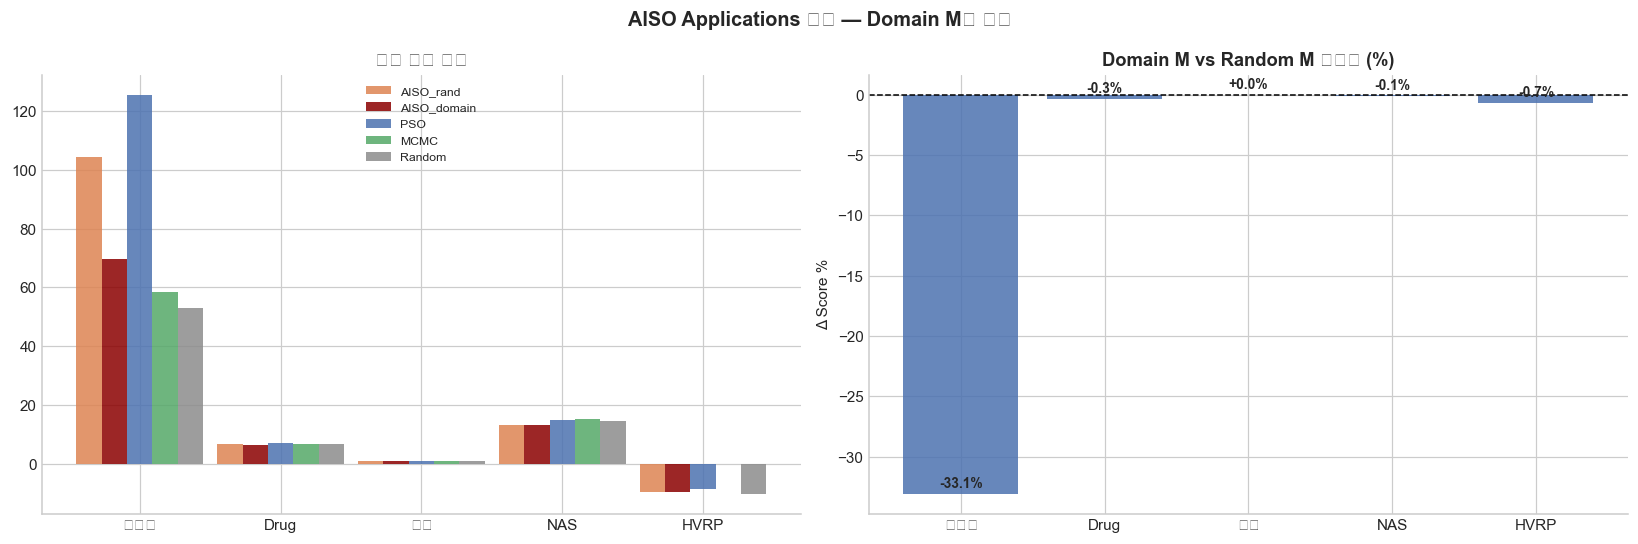


=== 종합 결과 ===
  단백질      1등=PSO            domain M 개선=-34.478
  Drug     1등=PSO            domain M 개선=-0.022
  추천       1등=PSO            domain M 개선=+0.000
  NAS      1등=MCMC           domain M 개선=-0.010
  HVRP     1등=PSO            domain M 개선=-0.067


In [13]:
# ================================================================
# 종합 요약 — domain M vs random M 효과
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

APPS = [
    ('단백질', RES_PROTEIN),
    ('Drug',   RES_DRUG),
    ('추천',   RES_REC),
    ('NAS',    RES_NAS),
    ('HVRP',   RES_HVRP),
]

x = np.arange(len(APPS))
w = 0.18
for i, alg in enumerate(['AISO_rand','AISO_domain','PSO','MCMC','Random']):
    vals = []
    for _, res in APPS:
        if alg in res:
            vals.append(res[alg]['mean'])
        else:
            vals.append(np.nan)
    # 정규화: 각 앱별 최고/최저로 0~1 스케일
    axes[0].bar(x + i*w - 2*w, vals, w, label=alg,
                color=COLORS.get(alg,'gray'), alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels([a[0] for a in APPS])
axes[0].set_title('앱별 절대 점수', fontweight='bold')
axes[0].legend(frameon=False, fontsize=8)

# domain M vs random M 개선율
improve = []
for _, res in APPS:
    if 'AISO_rand' in res and 'AISO_domain' in res:
        base = res['AISO_rand']['mean']
        dom  = res['AISO_domain']['mean']
        improve.append((dom - base) / abs(base + 1e-8) * 100)
    else:
        improve.append(0)

bars = axes[1].bar([a[0] for a in APPS], improve,
                   color=['#8B0000' if v>0 else '#4C72B0' for v in improve],
                   alpha=0.85)
axes[1].axhline(0, color='k', ls='--', lw=1)
axes[1].set_title('Domain M vs Random M 개선율 (%)', fontweight='bold')
axes[1].set_ylabel('Δ Score %')
for bar, val in zip(bars, improve):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:+.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('AISO Applications 종합 — Domain M의 효과', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig('app_summary.png', bbox_inches='tight'); plt.show()

print('\n=== 종합 결과 ===')
for name, res in APPS:
    best = max(res, key=lambda k: res[k]['mean'])
    dom_imp = (res.get('AISO_domain',{}).get('mean',0) - res.get('AISO_rand',{}).get('mean',0))
    print(f'  {name:<8} 1등={best:<14} domain M 개선={dom_imp:+.3f}')